# Paramteric Instabilities
### Caroline Capuano
### Final Project

## <span style="color:pink"> What are parametric instabilities?

Parametric instabilities, or PI's, are a three-mode optomechanical feedback loop when a mirror's acoustic mode/mechanical mode couples with energy from the main laser. The acoustic mode couples with a strong carrier to a higher order optical mode. The instability occurs when the *parametric gain* exceeds 1 (see parametric gain section). Blair descirbes this phenonenom as an "uncontrolled laser powered amplification of acoustic vibrations of the mirrors"$.^{[1]}$

You can consider parametric instabilities as a feedback process:
1. The mirrors acoustic mode scatters the carrier light into a tranverse optical mode
2. The higher order mode (HOM) gets amplified by cavity
3. That beat produces a radiation-pressure force back on the mirror
4. If the feedback is strong enough, the acoustic mode amplitude will grow exponentially


Parametric instabilities are **power-limiting** instabilities. At high enough power, acoustic modes of the mirror can ring up uncontrollably and can cause the interferometer to loose lock. But, to acheive a high enough sensitivity you need a *high* power cavity, so PI's are a barrier to our sensitivity level if left undamped.

### <span style="color:lightblue">Mechanical Modes
Mechanical modes are the natural patterns of vibration that a solid object, like a mirror, can sustain. Every object has a discrete set of these patterns, each with its own characteristic frequency and shape. For example, when you strike a wine glass it rings at a specific pitch — that's its fundamental mechanical mode. A LIGO test mass is no different, except that instead of one or two audible tones it has thousands of distinct vibrational patterns spread across a wide frequency range. Each mode is characterized by two things: the frequency $\omega_m$ of how fast it oscillates, and the mode shape $\vec{u}_m(\vec{r})$. The mode shape describes which parts of the mirror surface move outward, which move inward, and which remain stationary at the nodes.

When investigating parametric instabilities, there are three key factors to consider: the frequency of the mode, the spacial overlap of the mode, and the quality factor $Q_m$. The quality factor describes how long it rings before friction damps it out.

Some types of mechanical modes:
- Drumhead modes — the flat faces of the cylinder flex in and out, like a drumhead being struck. These have the most overlap with the laser beam since the beam hits the flat face directly
- Butterfly modes — the cylinder pinches in alternating directions around its circumference

### <span style="color:orange">Step 1: Scattering Carrier Light
The mirror is simultaneously doing two things in this system: it's reflecting the main laser beam (a.k.a "pump field") that circulates in the cavity, and it's also vibrating due to one of its mechanical resonance modes. When the pump field reflects off a vibrating mirror surface, the mechanical motion phase-modulates the reflected light. 

A key aspect in this interaction is the overlap integral between the medanical mode shape and the optical mode shape on the mirror's surface -  the overlap between these two modes is what causes the scattered light $B_{m,n}$. If the mechanical mode has a spatial pattern that overlaps with a particular higher order optical mode, energy transfers efficiently into that mode. If the shapes are orthogonal, no scattering will occur into that mode regardless of how strongly the mirror vibrates. 
*If the mechanical mode has a node where the optical mode has an antinode, they cancel out and very little scattering occurs.*

$$ E_{\text{scatt,n}}=\dfrac{2 \pi i}{\lambda_0} A_m E_{\text{pump}} B_{m,n} $$

The scattering produces two new frequency components: an upper sideband ($\omega_o - \omega_m$) and a lower sideband ($\omega_o + \omega_m$), where $\omega_m$ is the mechanical resonance frequency.

#### Scattered light, so what?
What important about these created sidebands is that they are not lower order modes, $\text{TEM}_{00}$. They are **higher order modes**, HOMs, that are dependent on $B_{m,n}$. Because of this, a single mechanical mode can simultaneously scatter light into many different HOMs, each with its own overlap coefficient $B_{m,n}$.

$$B_{m,n} = \iint_{\text{surface}} f_0 \, f_n (\vec{u}_m \cdot \hat{z}) \, d\vec{r}_\perp$$

Once scattered into a HOM, the light doesn't just escape — it keeps circulating in the cavity.

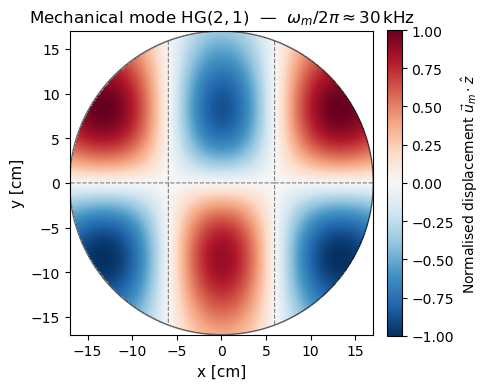

In [3]:


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.special import hermite


N        = 300      # grid resolution
mirror_r = 0.17     # mirror radius [m]

p_mech = 2
q_mech = 1


x = np.linspace(-mirror_r, mirror_r, N)
X, Y = np.meshgrid(x, x)
R    = np.sqrt(X**2 + Y**2)
mask = R <= mirror_r


def mechanical_mode(X, Y, p, q, mirror_r):
    """
    Synthetic drumhead mode using Hermite polynomials.
    Mimics the surface displacement normal to the mirror face.
    Replace with FEM output for a real calculation — see note below.
    """
    # scale so the mode fills the mirror face naturally
    scale = mirror_r * 0.7
    xi    = np.sqrt(2) * X / scale
    eta   = np.sqrt(2) * Y / scale
    Hp    = hermite(p)(xi)
    Hq    = hermite(q)(eta)
    env   = np.exp(-(X**2 + Y**2) / scale**2)
    u     = Hp * Hq * env
    return u / (np.max(np.abs(u)) + 1e-30)   # normalise to [-1, 1]

u_m = mechanical_mode(X, Y, p_mech, q_mech, mirror_r)

# mask outside aperture
u_display = u_m.copy()
u_display[~mask] = np.nan

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
extent = [-mirror_r * 100, mirror_r * 100,
          -mirror_r * 100, mirror_r * 100]   # axes in cm

vmax = 1.0
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(5, 5))

im = ax.imshow(u_display, extent=extent, origin='lower',
               cmap='RdBu_r', norm=norm)

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(mirror_r * 100 * np.cos(theta),
        mirror_r * 100 * np.sin(theta),
        'k-', lw=1.0, alpha=0.6)

x_cm = x * 100
ax.contour(x_cm, x_cm, u_display, levels=[0],
           colors='k', linewidths=0.8, linestyles='--', alpha=0.5)

plt.colorbar(im, ax=ax,
             label=r'Normalised displacement $\vec{u}_m \cdot \hat{z}$',
             fraction=0.046, pad=0.04)
ax.set_xlabel('x [cm]', fontsize=11)
ax.set_ylabel('y [cm]', fontsize=11)
ax.set_title(
    rf'Mechanical mode HG$({p_mech},{q_mech})$  —  '
    rf'$\omega_m / 2\pi \approx 30\,\mathrm{{kHz}}$',
    fontsize=12)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()



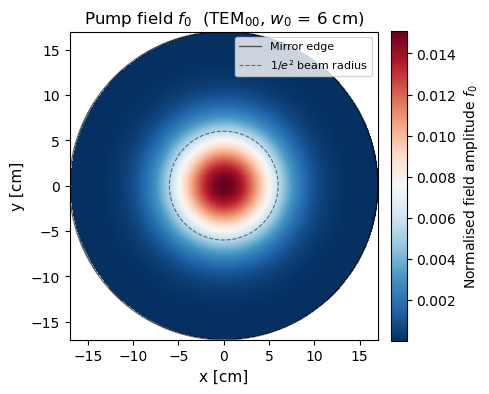

In [2]:
"""
Plot the TEM00 Gaussian pump field amplitude on the mirror surface.

Reference: Evans, Barsotti, Fritschel (2009), arXiv:0910.2716
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


N          = 300        # grid resolution
mirror_r   = 0.17       # mirror radius [m]
beam_waist = 0.06       # 1/e^2 beam radius [m]


x = np.linspace(-mirror_r, mirror_r, N)
X, Y = np.meshgrid(x, x)
R    = np.sqrt(X**2 + Y**2)
mask = R <= mirror_r


f0 = np.exp(-(X**2 + Y**2) / beam_waist**2)
f0 /= np.sqrt(np.sum(f0**2))

# mask outside aperture
f0_display = f0.copy()
f0_display[~mask] = np.nan

extent = [-mirror_r * 100, mirror_r * 100,
          -mirror_r * 100, mirror_r * 100]   # axes in cm

fig, ax = plt.subplots(figsize=(5, 5))

im = ax.imshow(f0_display, extent=extent, origin='lower',
               cmap='RdBu_r')

# mirror aperture circle
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(mirror_r * 100 * np.cos(theta),
        mirror_r * 100 * np.sin(theta),
        'k-', lw=1.0, alpha=0.6, label='Mirror edge')

# 1/e^2 beam radius circle
ax.plot(beam_waist * 100 * np.cos(theta),
        beam_waist * 100 * np.sin(theta),
        'k--', lw=0.8, alpha=0.5, label=r'$1/e^2$ beam radius')

plt.colorbar(im, ax=ax, label='Normalised field amplitude $f_0$',
             fraction=0.046, pad=0.04)

ax.set_xlabel('x [cm]', fontsize=11)
ax.set_ylabel('y [cm]', fontsize=11)
ax.set_title(r'Pump field $f_0$  (TEM$_{00}$, $w_0$ = 6 cm)', fontsize=12)
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

Strongest overlap: HG(0,1)  B = -4.0436e-07 m


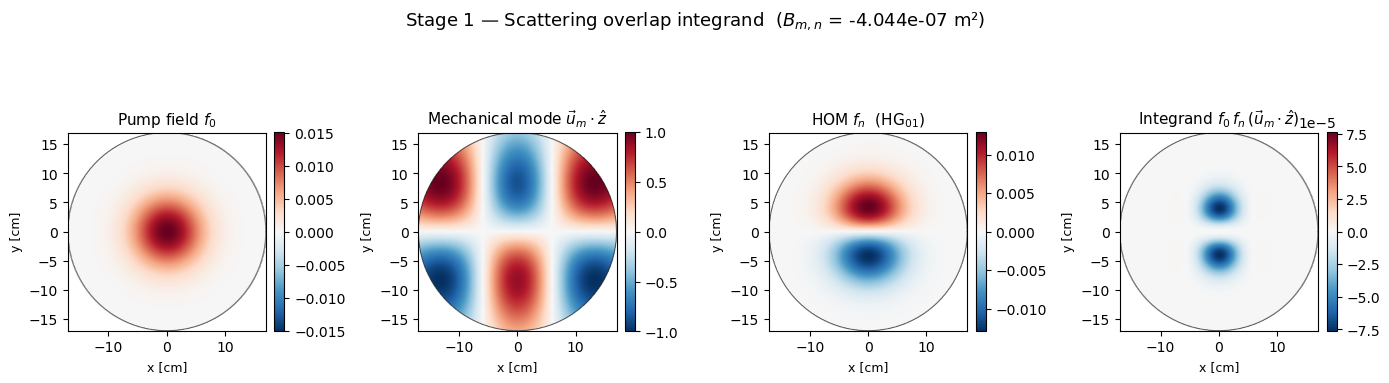

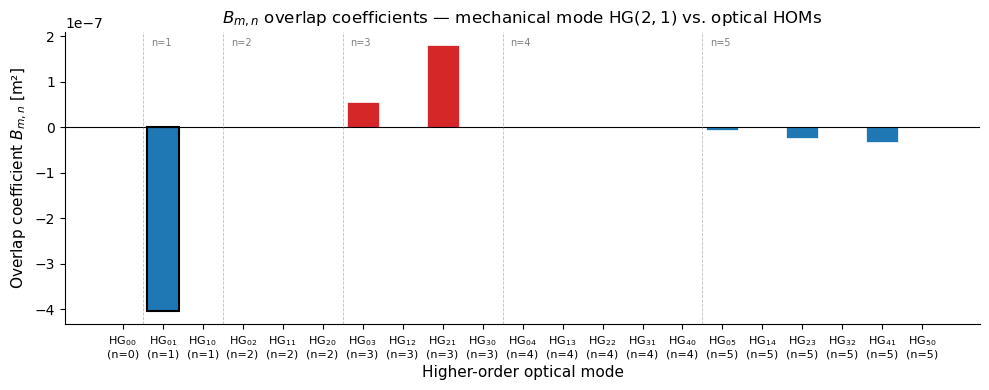

In [4]:
"""
Overlap integral map for Stage 1 of the PI feedback loop.

Visualizes the integrand  f0 * fn * (u_m . z_hat)  on the mirror surface,
showing where on the mirror face the scattering occurs, and produces:

  1. Side-by-side mode shapes  (pump f0, mechanical u_m, HOM fn)
  2. Integrand heatmap         (the spatial scattering contribution)
  3. B_{m,n} bar chart         (overlap coefficients for all HOM orders)

Reference: Evans, Barsotti, Fritschel (2009), arXiv:0910.2716
           Blair PhD thesis, UWA (2017)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import hermite
from matplotlib.colors import TwoSlopeNorm

# ─────────────────────────────────────────────────────────────────
# 1.  Grid and mirror parameters  (Advanced LIGO test mass)
# ─────────────────────────────────────────────────────────────────
N          = 300                # grid points per side
mirror_r   = 0.17               # mirror radius [m]  17 cm
beam_waist = 0.06               # 1/e^2 beam radius  [m]  ~6 cm

x = np.linspace(-mirror_r, mirror_r, N)
y = np.linspace(-mirror_r, mirror_r, N)
X, Y = np.meshgrid(x, y)
R    = np.sqrt(X**2 + Y**2)
mask = R <= mirror_r            # aperture mask

# ─────────────────────────────────────────────────────────────────
# 2.  Field functions
# ─────────────────────────────────────────────────────────────────

def gaussian_beam(X, Y, w0):
    """TEM00 pump field amplitude (real, normalised)."""
    f = np.exp(-(X**2 + Y**2) / w0**2)
    f /= np.sqrt(np.sum(f**2))
    return f


def hermite_gauss(p, q, X, Y, w0):
    """
    HG_{pq} field amplitude on grid (signed, normalised).
    Uses physicists' Hermite polynomials via scipy.
    """
    xi = np.sqrt(2) * X / w0
    eta = np.sqrt(2) * Y / w0
    Hp  = hermite(p)(xi)
    Hq  = hermite(q)(eta)
    env = np.exp(-(X**2 + Y**2) / w0**2)
    f   = Hp * Hq * env
    norm = np.sqrt(np.sum(f**2)) + 1e-30
    return f / norm


def mechanical_mode(X, Y, p_mech=2, q_mech=1):
    """
    Synthetic mechanical mode  u_m . z_hat.
    Uses a product of Hermite polynomials to mimic a drumhead mode.
    Replace with FEM output for a real calculation.
    """
    xi  = np.sqrt(2) * X / (mirror_r * 0.7)
    eta = np.sqrt(2) * Y / (mirror_r * 0.7)
    Hp  = hermite(p_mech)(xi)
    Hq  = hermite(q_mech)(eta)
    env = np.exp(-(X**2 + Y**2) / (mirror_r * 0.7)**2)
    u   = Hp * Hq * env
    return u / (np.max(np.abs(u)) + 1e-30)   # normalise to [-1, 1]


# ─────────────────────────────────────────────────────────────────
# 3.  Compute overlap coefficients B_{m,n} for HOM orders 0..5
# ─────────────────────────────────────────────────────────────────
# HOM pairs to include (all (p,q) with p+q <= max_order)
max_order = 5
hom_pairs = [(p, q) for n in range(max_order + 1)
                     for p in range(n + 1)
                     for q in [n - p]]

f0   = gaussian_beam(X, Y, beam_waist)
u_m  = mechanical_mode(X, Y, p_mech=2, q_mech=1)
dA   = (x[1] - x[0])**2          # area element [m^2]

B = {}
for (p, q) in hom_pairs:
    fn          = hermite_gauss(p, q, X, Y, beam_waist)
    integrand   = f0 * fn * u_m
    integrand[~mask] = 0.0
    B[(p, q)]   = np.sum(integrand) * dA

# ─────────────────────────────────────────────────────────────────
# 4.  Choose the HOM with largest |B| for detailed visualisation
# ─────────────────────────────────────────────────────────────────
best_mode = max(B, key=lambda k: abs(B[k]))
p_best, q_best = best_mode
fn_best    = hermite_gauss(p_best, q_best, X, Y, beam_waist)
integrand_best = f0 * fn_best * u_m
integrand_best[~mask] = 0.0

print(f"Strongest overlap: HG({p_best},{q_best})  "
      f"B = {B[best_mode]:.4e} m")

# ─────────────────────────────────────────────────────────────────
# 5.  Colourmap helper  (signed: red = +, blue = -)
# ─────────────────────────────────────────────────────────────────
signed_cmap = 'RdBu_r'

def signed_norm(arr):
    """TwoSlopeNorm centred on 0 for signed arrays."""
    valid = arr[~np.isnan(arr)]
    vmax = np.max(np.abs(valid)) + 1e-30 if len(valid) > 0 else 1.0
    return TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# ─────────────────────────────────────────────────────────────────
# 6.  Figure 1 — mode shapes + integrand heatmap
# ─────────────────────────────────────────────────────────────────
fig1, axes = plt.subplots(1, 4, figsize=(14, 4))
extent = [-mirror_r*100, mirror_r*100,
          -mirror_r*100, mirror_r*100]   # display in cm

titles  = [r'Pump field $f_0$',
           r'Mechanical mode $\vec{u}_m \cdot \hat{z}$',
           rf'HOM $f_{{n}}$  (HG$_{{{p_best}{q_best}}}$)',
           r'Integrand $f_0 \, f_n \, (\vec{u}_m \cdot \hat{z})$']
arrays  = [f0, u_m, fn_best, integrand_best]

for ax, arr, title in zip(axes, arrays, titles):
    disp = arr.copy()
    disp[~mask] = np.nan
    norm = signed_norm(disp)
    im = ax.imshow(disp, extent=extent, origin='lower',
                   cmap=signed_cmap, norm=norm)
    # mirror aperture circle
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(mirror_r*100*np.cos(theta),
            mirror_r*100*np.sin(theta),
            'k-', lw=0.8, alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x [cm]', fontsize=9)
    ax.set_ylabel('y [cm]', fontsize=9)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig1.suptitle(
    rf'Stage 1 — Scattering overlap integrand  '
    rf'($B_{{m,n}}$ = {B[best_mode]:.3e} m²)',
    fontsize=13, y=1.01)
fig1.tight_layout()


# ─────────────────────────────────────────────────────────────────
# 7.  Figure 2 — B_{m,n} bar chart for all HOM pairs
# ─────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4))

labels  = [f'HG$_{{{p}{q}}}$\n(n={p+q})' for (p, q) in hom_pairs]
values  = [B[(p, q)] for (p, q) in hom_pairs]
colors  = ['#d62728' if v > 0 else '#1f77b4' for v in values]

bars = ax2.bar(range(len(hom_pairs)), values, color=colors,
               edgecolor='white', linewidth=0.5)

# highlight best mode
best_idx = hom_pairs.index(best_mode)
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(1.5)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(range(len(hom_pairs)))
ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylabel(r'Overlap coefficient $B_{m,n}$ [m²]', fontsize=11)
ax2.set_xlabel('Higher-order optical mode', fontsize=11)
ax2.set_title(
    r'$B_{m,n}$ overlap coefficients — '
    r'mechanical mode HG$(2,1)$ vs. optical HOMs',
    fontsize=12)

# add order dividers
orders = sorted(set(p+q for p,q in hom_pairs))
for n in orders[:-1]:
    # find last index of this order
    idx = max(i for i,(p,q) in enumerate(hom_pairs) if p+q == n)
    ax2.axvline(idx + 0.5, color='gray', linestyle='--',
                linewidth=0.6, alpha=0.5)
    ax2.text(idx + 0.7, ax2.get_ylim()[1]*0.85,
             f'n={n+1}', fontsize=7, color='gray')

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
fig2.tight_layout()

plt.show()

Output()

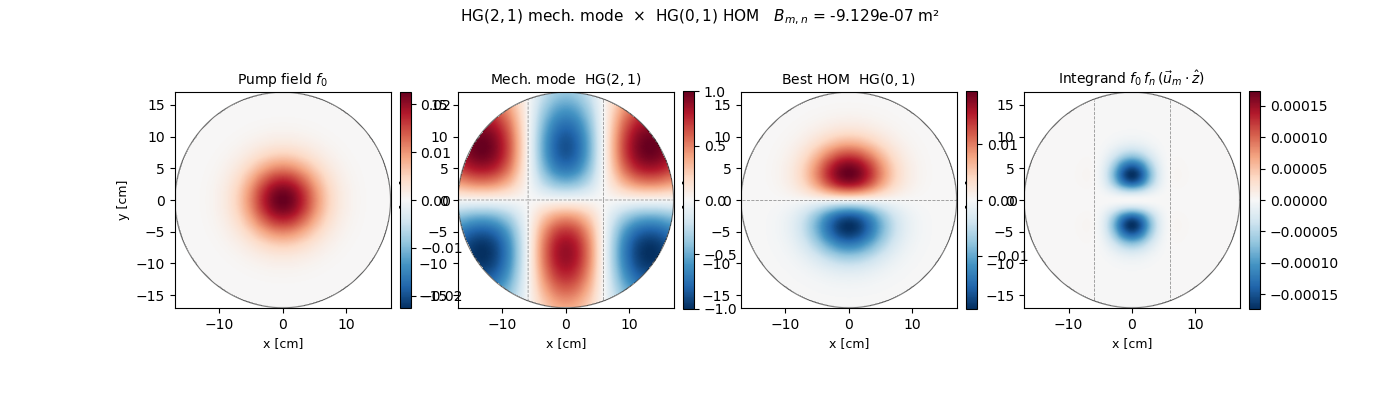

In [6]:
%matplotlib widget
"""
Interactive Stage 1 — Scattering overlap integral map.

Sliders for p_mech and q_mech update the mechanical mode,
best-overlap HOM, and integrand panels in real time.

Run in a Jupyter notebook with:
    %matplotlib widget        ← in the first cell

Reference: Evans, Barsotti, Fritschel (2009), arXiv:0910.2716
           Blair PhD thesis, UWA (2017)
"""

# ── put  %matplotlib widget  in the cell above this one ──────────

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.special import hermite
import ipywidgets as widgets
from IPython.display import display

# ─────────────────────────────────────────────────────────────────
# 1.  Grid and mirror parameters
# ─────────────────────────────────────────────────────────────────
N          = 200        # lower res for faster interaction
mirror_r   = 0.17       # mirror radius [m]
beam_waist = 0.06       # 1/e^2 beam radius [m]

x = np.linspace(-mirror_r, mirror_r, N)
X, Y = np.meshgrid(x, x)
R    = np.sqrt(X**2 + Y**2)
mask = R <= mirror_r
dA   = (x[1] - x[0])**2
extent = [-mirror_r*100, mirror_r*100, -mirror_r*100, mirror_r*100]
theta  = np.linspace(0, 2*np.pi, 300)

# ─────────────────────────────────────────────────────────────────
# 2.  Field functions  (unchanged from previous scripts)
# ─────────────────────────────────────────────────────────────────

def gaussian_beam(X, Y, w0):
    """TEM00 pump field amplitude (real, normalised)."""
    f = np.exp(-(X**2 + Y**2) / w0**2)
    f /= np.sqrt(np.sum(f**2))
    return f


def hermite_gauss(p, q, X, Y, w0):
    """HG_{pq} field amplitude (signed, normalised)."""
    xi  = np.sqrt(2) * X / w0
    eta = np.sqrt(2) * Y / w0
    Hp  = hermite(p)(xi)
    Hq  = hermite(q)(eta)
    env = np.exp(-(X**2 + Y**2) / w0**2)
    f   = Hp * Hq * env
    return f / (np.sqrt(np.sum(f**2)) + 1e-30)


def mechanical_mode(X, Y, p_mech, q_mech):
    """
    Synthetic drumhead mode  u_m . z_hat  (normalised to [-1, 1]).
    Replace with np.load('fem_mode.npy') for real FEM data.
    """
    scale = mirror_r * 0.7
    xi    = np.sqrt(2) * X / scale
    eta   = np.sqrt(2) * Y / scale
    Hp    = hermite(p_mech)(xi)
    Hq    = hermite(q_mech)(eta)
    env   = np.exp(-(X**2 + Y**2) / scale**2)
    u     = Hp * Hq * env
    return u / (np.max(np.abs(u)) + 1e-30)


def signed_norm(arr):
    """TwoSlopeNorm centred on 0 for signed arrays."""
    valid = arr[~np.isnan(arr)]
    vmax  = np.max(np.abs(valid)) + 1e-30 if len(valid) > 0 else 1.0
    return TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)


def compute_best_hom(u_m, f0):
    """Find HOM with largest |B_{m,n}| given mechanical mode u_m."""
    hom_pairs = [(p, q) for n in range(6)
                         for p in range(n + 1)
                         for q in [n - p]]
    B = {}
    for (p, q) in hom_pairs:
        fn               = hermite_gauss(p, q, X, Y, beam_waist)
        integrand        = f0 * fn * u_m
        integrand[~mask] = 0.0
        B[(p, q)]        = np.sum(integrand) * dA
    best = max(B, key=lambda k: abs(B[k]))
    return best, B[best]


# ─────────────────────────────────────────────────────────────────
# 3.  Pre-compute fixed pump field
# ─────────────────────────────────────────────────────────────────
f0 = gaussian_beam(X, Y, beam_waist)

# ─────────────────────────────────────────────────────────────────
# 4.  Build figure with four panels
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
plt.subplots_adjust(top=0.88, bottom=0.12)

titles_fixed = [
    r'Pump field $f_0$',
    r'Mechanical mode $\vec{u}_m \cdot \hat{z}$',
    r'Best-overlap HOM $f_n$',
    r'Integrand $f_0\,f_n\,(\vec{u}_m \cdot \hat{z})$'
]

# initialise with p=2, q=1
p0, q0    = 2, 1
u_m_init  = mechanical_mode(X, Y, p0, q0)
(pb, qb), B_val = compute_best_hom(u_m_init, f0)
fn_init   = hermite_gauss(pb, qb, X, Y, beam_waist)
intg_init = f0 * fn_init * u_m_init
intg_init[~mask] = 0.0

init_arrays = [f0, u_m_init, fn_init, intg_init]
ims, cbs = [], []

for ax, arr, title in zip(axes, init_arrays, titles_fixed):
    disp        = arr.copy()
    disp[~mask] = np.nan
    im = ax.imshow(disp, extent=extent, origin='lower',
                   cmap='RdBu_r', norm=signed_norm(disp))
    ax.plot(mirror_r*100*np.cos(theta),
            mirror_r*100*np.sin(theta),
            'k-', lw=0.8, alpha=0.5)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x [cm]', fontsize=9)
    ax.set_ylabel('y [cm]', fontsize=9)
    ax.set_aspect('equal')
    ims.append(im)
    cbs.append(cb)

fig.suptitle(
    rf'Stage 1 — overlap integrand   '
    rf'HG$({p0},{q0})$ mech. mode  ×  HG$({pb},{qb})$ HOM   '
    rf'$B_{{m,n}}$ = {B_val:.3e} m²',
    fontsize=11)

# ─────────────────────────────────────────────────────────────────
# 5.  Update function called by sliders
# ─────────────────────────────────────────────────────────────────
def update(p_mech, q_mech):
    u_m = mechanical_mode(X, Y, p_mech, q_mech)
    (pb, qb), B_val = compute_best_hom(u_m, f0)
    fn_best        = hermite_gauss(pb, qb, X, Y, beam_waist)
    integrand_best = f0 * fn_best * u_m
    integrand_best[~mask] = 0.0

    new_arrays = [f0, u_m, fn_best, integrand_best]
    new_titles = [
        r'Pump field $f_0$',
        rf'Mech. mode  HG$({p_mech},{q_mech})$',
        rf'Best HOM  HG$({pb},{qb})$',
        r'Integrand $f_0\,f_n\,(\vec{u}_m \cdot \hat{z})$'
    ]

    for ax, im, arr, title in zip(axes, ims, new_arrays, new_titles):
        disp        = arr.copy()
        disp[~mask] = np.nan
        norm        = signed_norm(disp)
        im.set_data(disp)
        im.set_norm(norm)
        ax.set_title(title, fontsize=10)
        # redraw nodal contours
        for coll in ax.collections:
            coll.remove()
        ax.contour(x*100, x*100, disp, levels=[0],
                   colors='k', linewidths=0.6, linestyles='--', alpha=0.4)

    fig.suptitle(
        rf'HG$({p_mech},{q_mech})$ mech. mode  ×  HG$({pb},{qb})$ HOM   '
        rf'$B_{{m,n}}$ = {B_val:.3e} m²',
        fontsize=11)
    fig.canvas.draw_idle()

# ─────────────────────────────────────────────────────────────────
# 6.  Sliders
# ─────────────────────────────────────────────────────────────────
slider_p = widgets.IntSlider(
    value=2, min=0, max=5, step=1,
    description=r'p (mech)',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'))

slider_q = widgets.IntSlider(
    value=1, min=0, max=5, step=1,
    description=r'q (mech)',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='400px'))

label = widgets.HTML(
    value='<b>Mechanical mode order:</b>  '
          'p = nodal lines in x,  q = nodal lines in y')

ui = widgets.VBox([
    label,
    widgets.HBox([slider_p, slider_q])
])

out = widgets.interactive_output(update, {'p_mech': slider_p,
                                          'q_mech': slider_q})
display(ui, out)

### <span style="color:lightcoral">Step 2: HOM Amplification
The circulation of the sidebands in the cavity will cause them to pick up a phase each round trip ($\phi_{\text{total}} = \phi_{\text{prop}} + \phi_{\text{gouy}}$, where $\phi_{\text{prop}} = \dfrac{4 \pi f L}{c}$ and $\phi_{\text{gouy}} = n \phi_G$). Let's look at the cavity:

The scattering and mirror matrixes are not difficult at all, just model a simple fabry-perot cavity with the HOM sidebands circulating.

<div style="text-align: center;">

![Arm Cavity](pi_cavity.png)

<p style="font-size: 12px;"></p>

</div>

Graph representation:

<div style="text-align: center;">

<img src="pi_directed_graph_cavity.png" alt="Directed graph" width="700"/>

<p style="font-size: 12px;"></p>

</div>

$$E_{\text{refl}} = r_1E_{\text{in}} + t_1E_{\text{cav2}} = \boxed{\dfrac{r_1 - r_2e^{2ikL}}{1-r_1r_2e^{2ikL}} E_{\text{in}}}$$
$$E_{\text{cav}} = t_1E_{\text{in}} + (-r_1e^{ikL})(-r_2e^{ikL})E_{\text{cav}} = \boxed{\dfrac{t_1}{1-r_1r_2e^{2ikL}} E_{\text{in}}}$$
$$E_{\text{cav2}} = -r_2e^{ikL} E_{\text{cav}} = \boxed{\dfrac{-r_2e^{ikL} t_1}{1-r_1r_2e^{2ikL}} E_{\text{in}}}$$
$$E_{\text{trans}} = $$

Gain Coefficient from cavity:

$$G_n^\pm = \boxed{\dfrac{t_A}{1-r_Ar_Be^{i\phi_{total}^\pm}}} = \boxed{\dfrac{t_A}{1-r_Ar_Be^{i(\dfrac{2(\omega_0 \pm \omega_m)L}{c} - n \phi_{G, rt})}}}$$

### <span style="color:#CD5C5C"> Step 3: Radiation Pressure
After the scattered HOM has circulated around the cavity and been amplified, it comes back to the same mirror surface and interferes with the pump field. This is where the magic happens. The optical field can couple back into the mechanical mode. Instead of scattering, this interaction will cause a radiation pressure on the mirror.If the phase is right, this force drives the mechanical mode further — amplifying the original vibration rather than damping it. The mirror then scatters more light, which gets amplified, which pushes the mirror harder. 

$$F_{\text{rad}} = \dfrac{2}{c} E_{\text{pump}}^* \sum_{n=0}^\infty B_{m,n} E_{\text{return, n}}$$


### <span style="color:#FF474C"> Step 4: Instability

The parametric gain is how we understand how strongly the mode interaction drives the acoustic mode. Think of it like a threshold: consider the ratio of the radiation-pressure ennergy fed into the mode to the mechaincal energy the mode looses by damping. If the parametric gain is less than one, the the mode damping is dominating; if the parametric gain is equal to one, it is at the instability threshold; if the gain is greater than one, then the mode rings up and becomes unstable:
 - <span style="color:green">R_m &lt; 1 : the mode is damped</span> 
 - $R_m$ = 1 : intability threshold
 - <span style="color:red">R_m &gt; 1 : the mode rings up</span> 


Parametric gain equation:

$R_m = \dfrac{4 \pi Q_m P_{\text{circ}}}{M \omega^2_m c \lambda_0} \sum_{n=0}^\infty \mathbb{R}[G_n]B^2_{m,n}$

The parametric gain is directly portional to the mechaincal mode $Q_m$, power $P_{\text{circ}}$ and the spatial overlap between the optical and mechanical mode $B_{m,n}$. 

## <span style="color:#967BB6"> Modeling Mode Interaction

In [ ]:
import numpy as np

# parameters
L       = 3994.5 # arm length [m]
c       = 3e8  # speed of light [m/s]
FSR     = c / (2 * L) # ~37.5 kHz

# cavity
T_ITM   =  1 # input mirror power transmission
T_ETM   =  1 # end mirror power transmission
r_ITM   = np.sqrt(1 - T_ITM)
r_ETM   = np.sqrt(1 - T_ETM)

F       = np.pi * np.sqrt(r_ITM * r_ETM) / (1 - r_ITM * r_ETM) # cavity finesse 
delta   = FSR / (2 * F)   # half-linewidth [Hz]

gouy_rt = 1 # Gouy phase per round trip [radians] 

def cavity_amplitude(delta_f, mode_order, gouy_rt_rad, r1=r_ITM, r2=r_ETM, t1=np.sqrt(T_ITM)):
    """
    Cavity field amplitude for HOM of order n.
        delta_f  : frequency offset from carrier [Hz]
        mode_order: n 
    """

    phi_prop  = 4 * np.pi * delta_f * L / c   # round-trip propagation
    phi_gouy  = mode_order * gouy_rt_rad   # HOM Gouy shift (round-trip)
    phi_total = phi_prop - phi_gouy    # total round-trip phase

    denom = 1 - r1 * r2 * np.exp(1j * phi_total)
    return np.abs(t1 / denom)



### How are PI's damped in LIGO?
There are two main strategies for damping parametric instabilities: change the spatial overlap,  reduce the mechanical mode Q factor

#### 1. Thermal Tuning using Ring Heaters

This attacks the optical side of the feedback loop by shifting the HOM resonance frequencies away from mechanical mode frequencies. The mirror radius of curvature is not a fixed parameter but a dynamic and tunable variable. Since this curvature directly tunes the instability gain, it is possible to find a solution to instabilities over the range of mirror radii of curvature within which the detector will operate. LIGO uses a **ring heater** - a glass torus wrapped in nichrome wire through which current is dissipated to heat the barrel of the optic it encircles. It can be used to tune the g-factor and higher order mode spacing of the Fabry-Perot arms to assist in the control of parametric instabilities.

#### 2. Passive Damping using Acoustic Mode Dampers (AMDs)
Each test mass is equipped with four different AMDs distributed on the optic's flats. Each AMD is made of a base, a shunted shear plate and a reaction mass, where the shunted shear plate is used as a lossy tunable spring with a complex stiffness.

#### 3. Active Damping using Electrostatic Drive (ESD)
The electrostatic drive (ESD) damps parametric instabilities by s\applying a feedback force directly to the test mass surface at the same frequency but with opposite phase. This reduces the effective $Q_m$ of the unstable mode, which directly brings $\mathcal{R}_m​$ below 1.

<div style="text-align: center;">

![Damping PIs in LIGO](damping_pi_ligo.png)

<p style="font-size: 12px;">Figure 1: Damping PIs in LIGO. From Blair et al. (2017)<sup>[3]</sup></p>

</div>

## <span style="color:lightblue"> Resources

[1] Blair, Carl. *Parametric Instability in Gravitational Wave Detectors.* Diss. University of Western Australia, 2017.

[2] Evans, M., L. Barsotti, and P. Fritschel. "A General Approach to Optomechanical Parametric Instabilities." *arXiv,* 14 Oct. 2009, arXiv:0910.2716v1

[3] Blair, Carl, et al. "First Demonstration of Electrostatic Damping of Parametric Instability at Advanced LIGO." *Physical Review Letters*, vol. 118, no. 15, Apr. 2017, doi:10.1103/PhysRevLett.118.151102.

[4] 
